# Rhode Island bridge network — EDA

Source: FHWA National Bridge Inventory (NBI), 2025 delimited extract for Rhode Island
(`data/raw/RI25.csv`, 787 bridges). See `src/data_prep.py` for cleaning and
`src/risk_model.py` for the risk/cost scoring this feeds into.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.risk_model import add_risk_and_cost

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/processed/bridges.csv')
if 'risk_untreated' not in df.columns:
    df = add_risk_and_cost(df)
df.shape

(787, 16)

## Condition distribution

FHWA's own `BRIDGE_CONDITION` classification (Good / Fair / Poor).

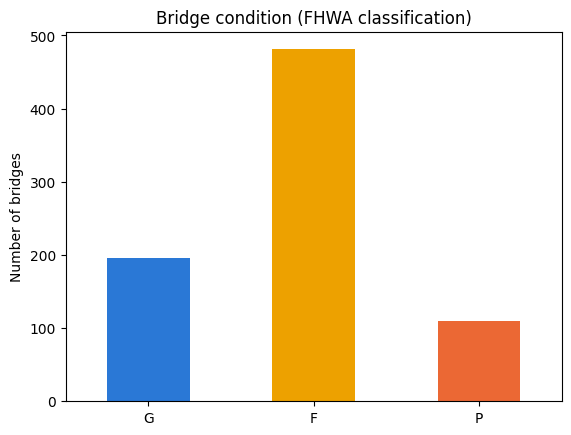

In [2]:
df['bridge_condition'].value_counts().reindex(['G','F','P']).plot(
    kind='bar', color=['#2a78d6', '#eda100', '#eb6834'], edgecolor='none'
)
plt.title('Bridge condition (FHWA classification)')
plt.ylabel('Number of bridges')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

14% of Rhode Island's bridges are rated Poor — this is the pool the investment plan is triaging across.

## Traffic (ADT) is heavily right-skewed

This is why `risk_model.criticality()` log-scales it before normalising — a linear scale would let a handful of interstate bridges swamp everything else.

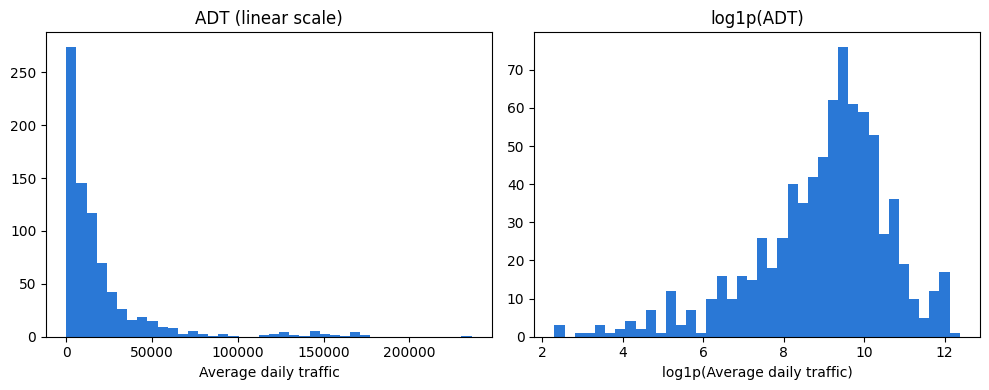

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['adt'], bins=40, color='#2a78d6')
axes[0].set_title('ADT (linear scale)')
axes[0].set_xlabel('Average daily traffic')

axes[1].hist(df['adt'].clip(lower=1).apply(lambda x: __import__('numpy').log1p(x)), bins=40, color='#2a78d6')
axes[1].set_title('log1p(ADT)')
axes[1].set_xlabel('log1p(Average daily traffic)')
plt.tight_layout()
plt.show()

## Risk score vs. condition and traffic

Risk is highest where poor condition and high traffic coincide — the bridges the model should prioritise.

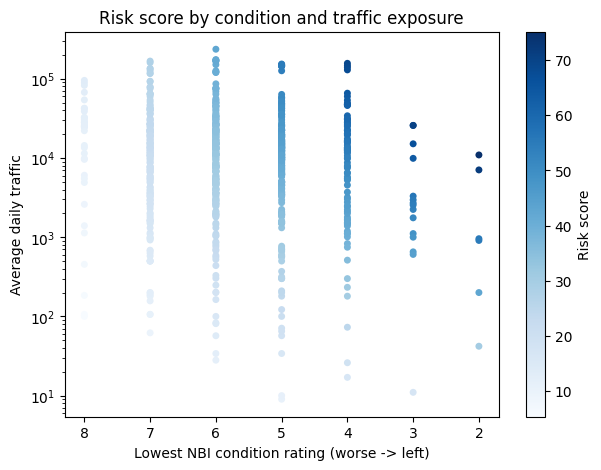

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df['lowest_rating'], df['adt'], c=df['risk_untreated'], cmap='Blues', s=25, edgecolor='none')
ax.set_xlabel('Lowest NBI condition rating (worse -> left)')
ax.set_ylabel('Average daily traffic')
ax.set_yscale('log')
ax.invert_xaxis()
cbar = plt.colorbar(sc)
cbar.set_label('Risk score')
plt.title('Risk score by condition and traffic exposure')
plt.show()

## Why worst-condition-first is not the same as cost-efficient

Ranking purely by condition ignores cost — a large, expensive, badly-rated bridge can cost 10x a smaller one for a similar risk reduction. This is exactly the gap the MILP closes; see `src/baseline.py` and the README for the full comparison.

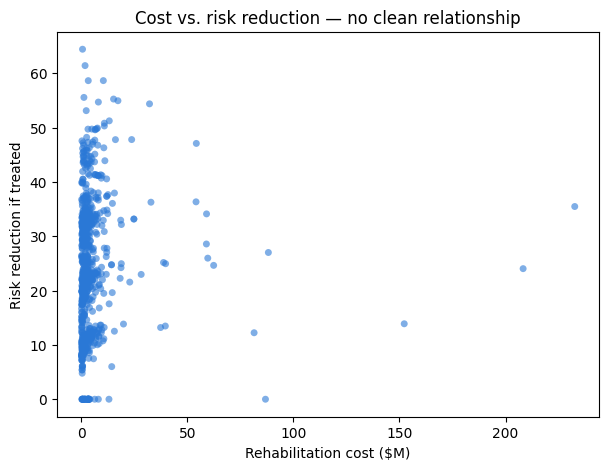

,structure_number,lowest_rating,adt,cost_usd,risk_reduction,risk_reduction_per_dollar
355,000000000005940,3,1000.0,190952.447112,39.885219,0.000209
593,000000000008610,2,200.0,177301.238576,36.740076,0.000207
131,000000000002920,2,957.0,346132.148964,47.558085,0.000137
576,000000000008430,4,1386.0,264430.488238,33.414474,0.000126
102,000000000002220,4,300.0,224134.752198,26.358364,0.000118
578,000000000008450,2,42.0,223641.335022,26.056729,0.000117
101,000000000002190,5,6200.0,270886.029624,30.248257,0.000112
100,000000000002130,5,11806.0,294158.873092,32.478936,0.000110
604,000000000008770,5,122.0,153822.804618,16.668853,0.000108
668,000000000009540,5,12300.0,306000.885316,32.620914,0.000107


In [5]:
df['risk_reduction_per_dollar'] = df['risk_reduction'] / df['cost_usd']
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['cost_usd'] / 1e6, df['risk_reduction'], c='#2a78d6', s=25, alpha=0.6, edgecolor='none')
ax.set_xlabel('Rehabilitation cost ($M)')
ax.set_ylabel('Risk reduction if treated')
ax.set_title('Cost vs. risk reduction — no clean relationship')
plt.show()

df[['structure_number','lowest_rating','adt','cost_usd','risk_reduction','risk_reduction_per_dollar']]\
    .sort_values('risk_reduction_per_dollar', ascending=False).head(10)